# Customer Churn Prediction Using Machine Learning and XGBoost

### An End-to-End Classification Project Using the IBM Telco Customer Churn Dataset

## 1. Project Overview

Customer churn occurs when customers stop using a company's service. Identifying customers who are likely to churn can help a company take actions to improve customer retention.

In this project, machine learning models will be developed to predict whether a telecommunications customer is likely to churn based on customer information, services, contract details, and billing information.

The project will compare several machine learning approaches, including a Decision Tree, Random Forest, and XGBoost.

### 1.1 Business Problem

Customer churn can lead to lost revenue and increased costs because acquiring new customers is often more expensive than retaining existing customers. A model that identifies customers at high risk of leaving could help the company target retention strategies more effectively.

### 1.2 Project Objective

The main objective of this project is to build and evaluate machine learning models that can predict whether a customer will churn.

The project will also investigate which customer characteristics are most strongly associated with churn.

### 1.3 Machine Learning Problem Type

This is a supervised machine learning classification problem.

The target variable is `Churn`:

- `Yes` = the customer left the company
- `No` = the customer remained with the company

Because there are two possible target classes, this is specifically a binary classification problem.

## 2. Dataset Overview

### 2.1 Dataset Description

The dataset contains information about telecommunications customers and whether they remained with the company or stopped using its services.

Each row represents one customer, while each column represents a characteristic or piece of information about that customer.

The dataset contains 7,043 customer observations and 21 columns.

The available information includes:

- Customer demographic information
- Account and contract information
- Phone and internet services
- Billing and payment information
- Monthly and total charges
- Customer churn status

### 2.2 Features and Target Variable

The target variable in this project is `Churn`.

The remaining useful customer attributes will be used as input features to help the machine learning models predict churn.

Some important features include:

- `tenure` — number of months the customer has stayed with the company
- `Contract` — type of customer contract
- `InternetService` — type of internet service
- `MonthlyCharges` — amount charged to the customer each month
- `TotalCharges` — total amount charged to the customer
- `PaymentMethod` — customer's payment method
- `TechSupport` — whether the customer receives technical support
- `OnlineSecurity` — whether the customer has online security service

The column `customerID` is a unique identifier for each customer and will not be used as a predictive feature.

## 3. Import Libraries

The required Python libraries are imported below. These libraries will be used for data manipulation, numerical operations, visualization, and later for building and evaluating machine learning models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 4. Load the Dataset

The dataset is loaded from a CSV file into a Pandas DataFrame. Loading the data into a DataFrame allows us to inspect, clean, analyze, and prepare the data for machine learning.

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 5. Initial Data Exploration

Before cleaning or building machine learning models, the dataset is explored to understand its size, structure, data types, and possible data quality issues.

### 5.1 Dataset Shape

In [3]:
df.shape

(7043, 21)

### 5.2 Columns and Data Types

The dataset columns and their data types are inspected to understand which variables are numerical and which are categorical. This is important because different types of variables require different preprocessing steps before machine learning.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### 5.3 Checking for Hidden Blank Values

Although `df.info()` did not report any null values, missing information can sometimes be stored as empty strings or spaces instead of standard null values such as `NaN`.

To identify these hidden blank values, all text-based (`object`) columns are checked for empty or whitespace-only entries.

In [5]:
object_columns = df.select_dtypes(include="object").columns

for column in object_columns:
    blank_count = (df[column].str.strip() == "").sum()
    print(column, blank_count)

customerID 0
gender 0
Partner 0
Dependents 0
PhoneService 0
MultipleLines 0
InternetService 0
OnlineSecurity 0
OnlineBackup 0
DeviceProtection 0
TechSupport 0
StreamingTV 0
StreamingMovies 0
Contract 0
PaperlessBilling 0
PaymentMethod 0
TotalCharges 11
Churn 0


### 5.4 Investigating Missing Values in `TotalCharges`

The previous check identified 11 blank values in the `TotalCharges` column.

These rows are inspected to understand why the values are missing and to determine the most appropriate way to handle them.

In [6]:
df[df["TotalCharges"].str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


### 5.5 Handling Missing `TotalCharges` Values

All 11 customers with blank `TotalCharges` values have a `tenure` of 0 months.

Because these customers are new and have not yet accumulated charges over time, the blank `TotalCharges` values are replaced with 0.

The column is then converted from an `object` data type to a numerical data type so that it can be used by the machine learning models.

In [7]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", "0")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [8]:
df["TotalCharges"].dtype

dtype('float64')

### 5.6 Checking for Duplicate Records

Duplicate records can distort the analysis and cause the machine learning model to learn from repeated observations.

The dataset is checked for completely duplicated rows before continuing with the analysis.

In [9]:
df.duplicated().sum()

np.int64(0)

### 5.7 Target Variable Distribution

Before building the machine learning models, the distribution of the target variable `Churn` is examined.

This helps determine whether the two target classes are balanced or whether one class appears much more frequently than the other.

In [10]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

The target variable is moderately imbalanced. Approximately 73.5% of customers did not churn, while 26.5% of customers churned.

This imbalance is important when evaluating the machine learning models because accuracy alone may not provide a complete picture of model performance. Metrics such as precision, recall, and F1-score will also be considered.

In [11]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### 5.8 Churn Distribution Visualization

The distribution of the target variable is visualized to make the class imbalance easier to understand.

A bar chart is used to compare the number of customers who churned with the number who remained with the company.

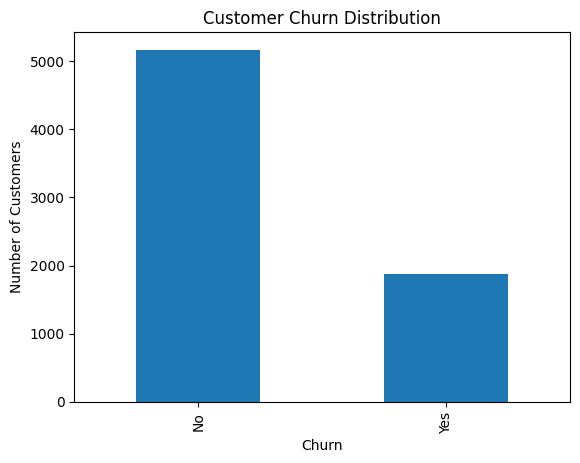

In [12]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

#### Interpretation

The chart shows that customers who did not churn represent the majority of the dataset.

There are 5,174 customers who did not churn compared with 1,869 customers who churned. This corresponds to approximately 73.5% non-churners and 26.5% churners.

Therefore, the target variable has a moderate class imbalance. This will be considered later when evaluating the machine learning models.

### 5.9 Contract Type and Customer Churn

Contract type may influence whether a customer remains with the company.

The churn rate for each contract type is examined to determine whether customers with different contract lengths show different churn behavior.

In [13]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


#### Interpretation

Contract type shows a strong relationship with customer churn.

Approximately 42.7% of customers with month-to-month contracts churned, compared with 11.3% of customers with one-year contracts and only 2.8% of customers with two-year contracts.

This suggests that customers with longer-term contracts are much less likely to churn than customers with month-to-month contracts.

### 5.10 Visualizing Churn Rate by Contract Type

The churn percentages for each contract type are visualized to make the differences between customer groups easier to compare.

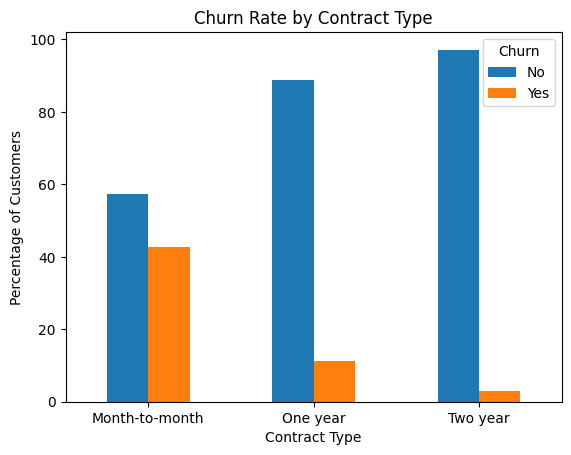

In [14]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.show()

### 5.11 Tenure and Customer Churn

Customer tenure represents the number of months a customer has remained with the company.

The tenure distribution is compared between customers who churned and customers who stayed to investigate whether newer or longer-term customers show different churn behavior.

In [15]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


#### Interpretation

Customers who churned had substantially shorter tenure than customers who remained with the company.

The average tenure for customers who churned was approximately 18 months, compared with about 38 months for customers who did not churn.

The median tenure also showed a large difference: 10 months for churned customers compared with 38 months for non-churned customers.

This suggests that newer customers may be at greater risk of churn, although the relationship does not by itself establish causation.

### 5.12 Visualizing Tenure by Churn Status

A box plot is used to compare the distribution of customer tenure between customers who churned and customers who remained with the company.

This visualization helps compare the median, quartiles, and overall spread of tenure for the two groups.

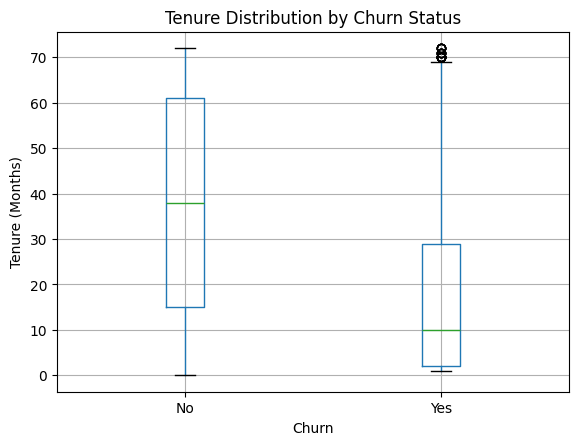

In [16]:
df.boxplot(column="tenure", by="Churn")

plt.title("Tenure Distribution by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

#### Interpretation

The box plot shows a clear difference in tenure between customers who churned and customers who remained with the company.

Customers who did not churn had a median tenure of approximately 38 months, while customers who churned had a median tenure of only 10 months.

The churned group is concentrated at lower tenure values, suggesting that newer customers are more strongly associated with churn. A small number of long-tenure customers also churned and appear as outliers in the churned group.

### 5.13 Monthly Charges and Customer Churn

Monthly charges represent the amount billed to each customer every month.

The monthly charges of customers who churned are compared with those who remained with the company to investigate whether billing amount is associated with churn.

In [17]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


#### Interpretation

Customers who churned generally had higher monthly charges than customers who remained with the company.

The average monthly charge for churned customers was approximately 74.44, compared with 61.27 for non-churned customers. The median monthly charge also showed a similar pattern.

This suggests that higher monthly charges may be associated with a greater likelihood of churn, although this relationship does not establish causation.

### 5.14 Visualizing Monthly Charges by Churn Status

A box plot is used to compare the distribution of monthly charges between customers who churned and customers who remained with the company.

This helps visualize differences in the median, quartiles, spread, and possible outliers between the two groups.

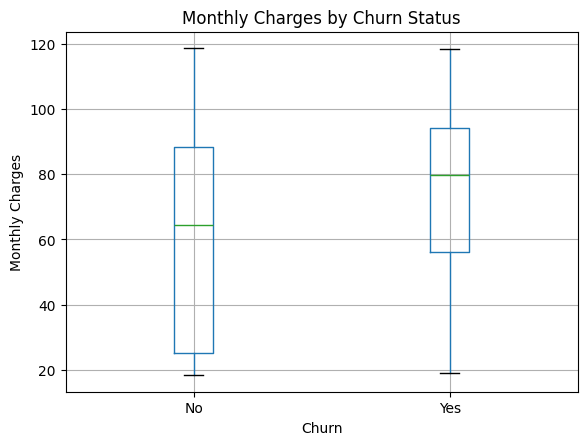

In [18]:
df.boxplot(column="MonthlyCharges", by="Churn")

plt.title("Monthly Charges by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

#### Interpretation

Customers who churned generally had higher monthly charges than customers who remained with the company.

The churned group had a noticeably higher median monthly charge, although there was substantial overlap between the two distributions.

This suggests that `MonthlyCharges` may provide useful predictive information, but it is unlikely to be sufficient on its own to distinguish churned customers from non-churned customers.

### 5.15 Internet Service and Customer Churn

Internet service type may influence customer satisfaction and churn behavior.

The churn rate is compared across different internet service categories to investigate whether customers using certain services are more likely to churn.

In [19]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


#### Interpretation

Customer churn varies substantially across internet service types.

Approximately 41.9% of customers using fiber-optic internet churned, compared with 19.0% of DSL customers and only 7.4% of customers without internet service.

Fiber-optic customers therefore show a considerably higher churn rate in this dataset. However, this relationship represents an association and does not establish that fiber-optic service itself causes customer churn.

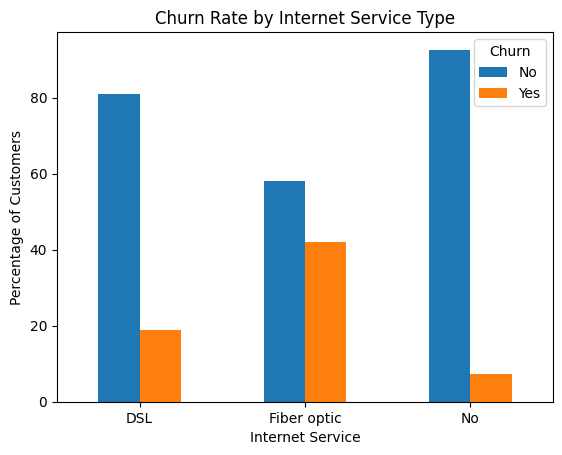

In [20]:
internet_churn.plot(kind="bar")

plt.title("Churn Rate by Internet Service Type")
plt.xlabel("Internet Service")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.show()

### 5.16 Payment Method and Customer Churn

Customer payment method may be associated with different churn behavior.

The churn rate is compared across payment methods to investigate whether customers using certain payment methods are more likely to leave the company.

In [21]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


#### Interpretation

Churn rates differ considerably across payment methods.

Customers using electronic checks had the highest churn rate at approximately 45.3%. In comparison, customers using automatic bank transfers, automatic credit card payments, or mailed checks had churn rates between approximately 15% and 19%.

This suggests that customers using electronic checks are more strongly associated with churn in this dataset. However, payment method alone should not be interpreted as causing churn because it may also be related to other customer characteristics such as contract type, tenure, or monthly charges.

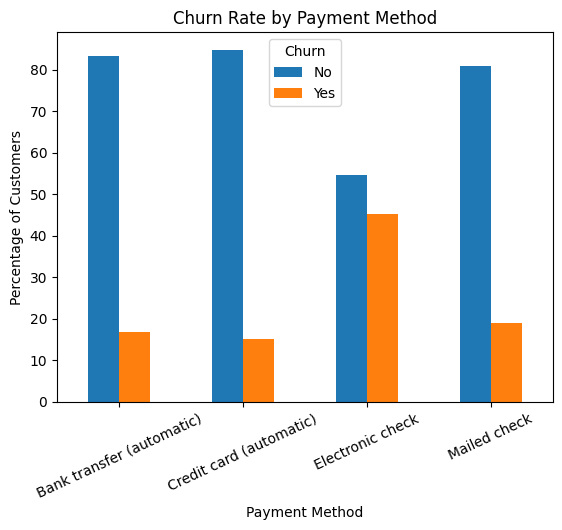

In [22]:
payment_churn.plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=25)
plt.show()

### 5.17 Technical Support and Customer Churn

Technical support may influence customer satisfaction and retention.

The churn rate is compared across technical support categories to investigate whether customers without technical support are more likely to leave the company.

In [23]:
techsupport_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

techsupport_churn

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


#### Interpretation

Customers without technical support had a substantially higher churn rate than customers who had technical support.

Approximately 41.6% of customers without technical support churned, compared with only 15.2% of customers who had technical support.

Customers categorized as `No internet service` had a much lower churn rate, but this represents a separate customer group that does not use internet services and therefore cannot directly be interpreted as a technical support effect.

Overall, the results suggest that the absence of technical support is strongly associated with customer churn among internet-service customers.

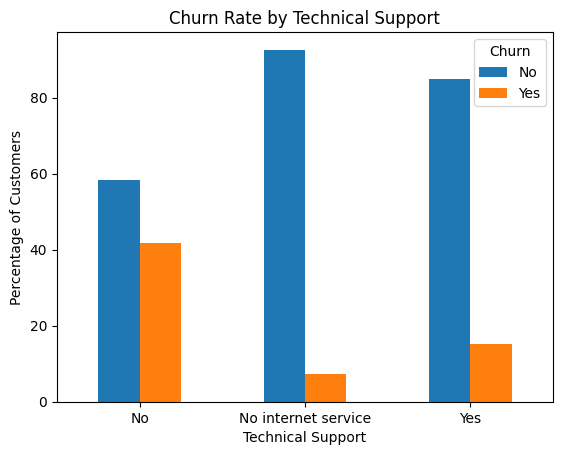

In [24]:
techsupport_churn.plot(kind="bar")

plt.title("Churn Rate by Technical Support")
plt.xlabel("Technical Support")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.show()

### 5.18 Online Security and Customer Churn

Online security services may influence customer satisfaction and retention.

The churn rate is compared across online security categories to investigate whether customers without online security are more likely to leave the company.

In [25]:
security_churn = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

security_churn

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


#### Interpretation

Customers without online security had a substantially higher churn rate than customers who had online security.

Approximately 41.8% of customers without online security churned, compared with only 14.6% of customers who had online security.

Customers categorized as `No internet service` had a lower churn rate, but this group does not use internet services and therefore should be interpreted separately.

Overall, the absence of online security is strongly associated with customer churn among internet-service customers.

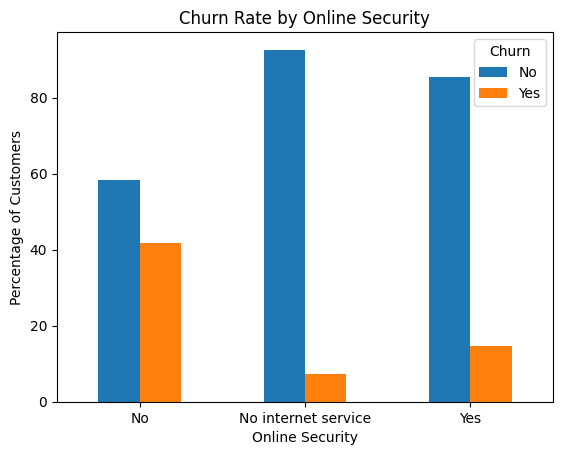

In [26]:
security_churn.plot(kind="bar")

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.show()

### 5.19 Exploratory Data Analysis Summary

The exploratory data analysis identified several customer characteristics that were strongly associated with churn.

Key findings include:

- Customers with month-to-month contracts had a much higher churn rate than customers with one-year or two-year contracts.
- Customers who churned generally had much shorter tenure than customers who remained with the company.
- Churned customers tended to have higher monthly charges.
- Fiber-optic internet customers showed a considerably higher churn rate than DSL customers or customers without internet service.
- Customers using electronic checks had a much higher churn rate than customers using other payment methods.
- Customers without technical support showed substantially higher churn rates than customers with technical support.
- Customers without online security also showed substantially higher churn rates.

These findings suggest that customer commitment, service characteristics, billing behavior, and access to support services may all provide useful information for predicting churn.

The relationships identified during EDA represent associations and should not be interpreted as proof of causation.

## 6. Data Preprocessing

Before training the machine learning models, the dataset must be prepared in a format that the algorithms can use.

This stage includes removing non-predictive identifiers, separating the input features from the target variable, encoding categorical variables, and splitting the dataset into training and testing sets.

### 6.1 Removing the Customer Identifier

The `customerID` column uniquely identifies each customer but does not describe a meaningful customer characteristic.

Because the identifier is not expected to provide useful predictive information, it is removed before model training.

In [27]:
df = df.drop("customerID", axis=1)

In [28]:
df.shape

(7043, 20)

### 6.2 Separating Features and Target Variable

The dataset is separated into input features (`X`) and the target variable (`y`).

The features contain the customer information that will be used by the machine learning models to make predictions, while the target contains the outcome that the models are trying to predict.

In [29]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [30]:
X.shape

(7043, 19)

In [31]:
y.shape

(7043,)

### 6.3 Encoding the Target Variable

The target variable `Churn` is currently stored as text values (`Yes` and `No`).

Machine learning models work with numerical values, so the target is converted into binary numerical labels:

- `No` = 0
- `Yes` = 1

In [32]:
y = y.map({"No": 0, "Yes": 1})

In [33]:
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

### 6.4 Identifying Categorical Features

Several input features contain categorical text values such as contract type, internet service, and payment method.

Before these features can be used by the machine learning models, the categorical columns are identified so they can be encoded into numerical form.

In [34]:
categorical_columns = X.select_dtypes(include="object").columns

categorical_columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

### 6.5 Train-Test Split

The dataset is divided into training and testing sets before fitting the preprocessing steps.

The training set is used to train the machine learning models, while the test set is kept separate and used only to evaluate how well the final models generalize to unseen customers.

A stratified split is used to preserve approximately the same churn proportion in both the training and testing sets.

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [36]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 19)
X_test: (1409, 19)
y_train: (5634,)
y_test: (1409,)


### 6.6 Preparing Categorical Features for One-Hot Encoding

The dataset contains several categorical features such as `Contract`, `InternetService`, and `PaymentMethod`.

These categorical variables will be converted into numerical binary columns using one-hot encoding.

The encoder will be fitted only on the training data so that information from the test set does not influence the preprocessing process.

In [38]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_columns = X_train.select_dtypes(include="object").columns
numerical_columns = X_train.select_dtypes(exclude="object").columns

In [39]:
preprocessor = ColumnTransformer(transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)],remainder="passthrough")

## 7. Baseline Model

Before training more advanced machine learning models, a simple baseline model is created.

The baseline provides a minimum level of performance that the more advanced models should outperform.

Because the majority of customers in the dataset did not churn, the baseline model will always predict the majority class.

In [40]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy_model = DummyClassifier(strategy="most_frequent")

dummy_model.fit(X_train, y_train)

y_dummy_pred = dummy_model.predict(X_test)

dummy_accuracy = accuracy_score(y_test, y_dummy_pred)

print("Baseline Accuracy:", dummy_accuracy)

Baseline Accuracy: 0.7345635202271115


# 8. Decision Tree Model

A Decision Tree is used as the first real machine learning model in this project.

Decision trees make predictions by repeatedly splitting the data based on feature values. Each split attempts to create groups that contain more similar target classes.

The preprocessing steps and Decision Tree model are combined into a pipeline. This ensures that categorical features are encoded consistently before the model is trained.

The model will first be evaluated using cross-validation on the training data. The test set will remain untouched until the final evaluation stage.


In [42]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

### 8.1 Cross-Validation

The Decision Tree is evaluated using 5-fold cross-validation on the training data.

In 5-fold cross-validation, the training data is divided into five subsets. The model is trained five times, using four folds for training and the remaining fold for validation. Each fold is used once as the validation set.

This provides a more reliable estimate of model performance than evaluating the model using a single validation split while keeping the final test set untouched.

In [43]:
from sklearn.model_selection import cross_val_score

dt_cv_scores = cross_val_score(
    decision_tree_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:", dt_cv_scores)
print("Mean CV accuracy:", dt_cv_scores.mean())

Cross-validation scores: [0.72670807 0.71162378 0.73469388 0.72582076 0.70870337]
Mean CV accuracy: 0.7215099739795524


In [44]:
dummy_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyClassifier(strategy="most_frequent"))
    ]
)

dummy_cv_scores = cross_val_score(
    dummy_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Dummy CV scores:", dummy_cv_scores)
print("Dummy Mean CV accuracy:", dummy_cv_scores.mean())

Dummy CV scores: [0.73469388 0.73469388 0.73469388 0.73469388 0.73445826]
Dummy Mean CV accuracy: 0.7346467539058252


### 8.2 Evaluation Beyond Accuracy

Because the target variable is imbalanced, accuracy alone may be misleading.

A model that predicts the majority class for every customer can achieve relatively high accuracy while failing to identify any customers who actually churn.

Therefore, the Decision Tree is also evaluated using precision, recall, and F1-score for the churn class.

In [45]:
from sklearn.model_selection import cross_validate

dt_cv_results = cross_validate(
    decision_tree_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=["accuracy", "precision", "recall", "f1"]
)

print("Mean Accuracy:", dt_cv_results["test_accuracy"].mean())
print("Mean Precision:", dt_cv_results["test_precision"].mean())
print("Mean Recall:", dt_cv_results["test_recall"].mean())
print("Mean F1:", dt_cv_results["test_f1"].mean())

Mean Accuracy: 0.7215099739795524
Mean Precision: 0.47625095757848757
Mean Recall: 0.4882943143812709
Mean F1: 0.48189086281895765


#### Decision Tree Cross-Validation Results

The Decision Tree achieved a mean cross-validation accuracy of approximately 72.2%.

However, because the dataset is moderately imbalanced, additional metrics provide a more useful understanding of model performance.

- **Precision:** approximately 47.6% of customers predicted to churn actually churned.
- **Recall:** the model identified approximately 48.8% of all customers who actually churned.
- **F1-score:** approximately 48.2%, reflecting the balance between precision and recall.

Although the Decision Tree achieved slightly lower accuracy than the majority-class baseline, unlike the baseline model it was able to identify a meaningful proportion of churned customers.

The results indicate that the default Decision Tree provides some predictive value but leaves substantial room for improvement.

# 9. Random Forest Model

A Random Forest is an ensemble learning algorithm that combines predictions from multiple decision trees.

Instead of relying on a single tree, Random Forest builds many trees using different samples of the training data and different subsets of features. The predictions from the individual trees are then combined to produce the final prediction.

Using multiple diverse trees can reduce overfitting and improve generalization compared with a single Decision Tree.

The Random Forest model is evaluated using the same 5-fold cross-validation procedure and the same evaluation metrics used for the Decision Tree.


In [47]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [48]:
rf_cv_results = cross_validate(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=["accuracy", "precision", "recall", "f1"]
)

print("Mean Accuracy:", rf_cv_results["test_accuracy"].mean())
print("Mean Precision:", rf_cv_results["test_precision"].mean())
print("Mean Recall:", rf_cv_results["test_recall"].mean())
print("Mean F1:", rf_cv_results["test_f1"].mean())

Mean Accuracy: 0.7870061670509582
Mean Precision: 0.6307384343778967
Mean Recall: 0.4775919732441471
Mean F1: 0.5433146669763974


#### Random Forest Cross-Validation Results

The Random Forest achieved stronger overall performance than the single Decision Tree.

The model achieved approximately 78.7% mean cross-validation accuracy, with a precision of 63.1%, recall of 47.8%, and F1-score of 54.3%.

Compared with the Decision Tree, the Random Forest produced substantially higher precision and F1-score while maintaining a similar level of recall.

This suggests that combining multiple decision trees improves overall predictive performance and reduces the instability associated with relying on a single tree. However, the recall indicates that the model still fails to identify a considerable proportion of customers who actually churn.

# 10. XGBoost Model

XGBoost (Extreme Gradient Boosting) is a tree-based ensemble learning algorithm that builds decision trees sequentially.

Unlike Random Forest, where many trees are built more independently and their predictions are combined, XGBoost builds trees one after another. Each new tree attempts to improve the errors made by the existing ensemble.

A baseline XGBoost model is first evaluated using the same 5-fold cross-validation procedure and evaluation metrics used for the previous models. Hyperparameter tuning will be performed later.


In [49]:
from xgboost import XGBClassifier

xgboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            random_state=42,
            n_jobs=-1,
            eval_metric="logloss"
        ))
    ]
)

In [50]:
xgb_cv_results = cross_validate(
    xgboost_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=["accuracy", "precision", "recall", "f1"]
)

print("Mean Accuracy:", xgb_cv_results["test_accuracy"].mean())
print("Mean Precision:", xgb_cv_results["test_precision"].mean())
print("Mean Recall:", xgb_cv_results["test_recall"].mean())
print("Mean F1:", xgb_cv_results["test_f1"].mean())

Mean Accuracy: 0.7841669280269061
Mean Precision: 0.6096124715200604
Mean Recall: 0.5197324414715718
Mean F1: 0.560934310800441


#### XGBoost Cross-Validation Results

The baseline XGBoost model achieved approximately 78.4% mean cross-validation accuracy, 61.0% precision, 52.0% recall, and an F1-score of 56.1%.

Compared with Random Forest, XGBoost achieved slightly lower accuracy and precision but higher recall and F1-score.

The higher recall indicates that XGBoost was able to identify a larger proportion of customers who actually churned, which is particularly important in a churn prediction problem where missing a high-risk customer may result in a lost retention opportunity.

Overall, XGBoost provided the strongest balance between precision and recall among the models tested so far.

## 11. Model Comparison

The cross-validation performance of the Decision Tree, Random Forest, and XGBoost models is compared using accuracy, precision, recall, and F1-score.

Using multiple evaluation metrics is important because the churn dataset is moderately imbalanced and accuracy alone does not show how effectively the models identify customers who actually churn.

In [51]:
model_comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "XGBoost"],
    "Accuracy": [
        dt_cv_results["test_accuracy"].mean(),
        rf_cv_results["test_accuracy"].mean(),
        xgb_cv_results["test_accuracy"].mean()
    ],
    "Precision": [
        dt_cv_results["test_precision"].mean(),
        rf_cv_results["test_precision"].mean(),
        xgb_cv_results["test_precision"].mean()
    ],
    "Recall": [
        dt_cv_results["test_recall"].mean(),
        rf_cv_results["test_recall"].mean(),
        xgb_cv_results["test_recall"].mean()
    ],
    "F1 Score": [
        dt_cv_results["test_f1"].mean(),
        rf_cv_results["test_f1"].mean(),
        xgb_cv_results["test_f1"].mean()
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.721510,0.476251,0.488294,0.481891
1,Random Forest,0.787006,0.630738,0.477592,0.543315
2,XGBoost,0.784167,0.609612,0.519732,0.560934


### 11.1 Visualizing Model Performance

The cross-validation results are visualized to compare the performance of the three models across accuracy, precision, recall, and F1-score.

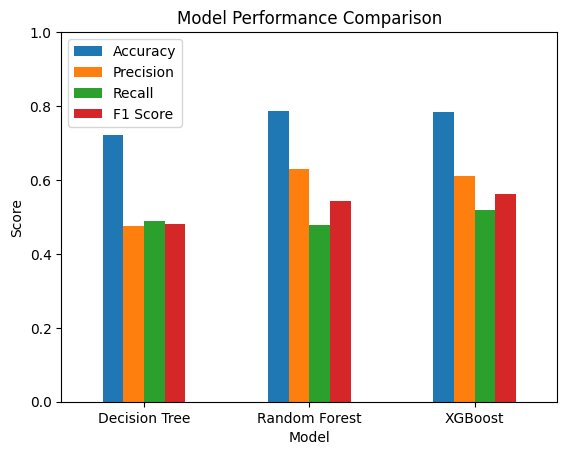

In [52]:
model_comparison.set_index("Model").plot(kind="bar")

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

#### Interpretation

Random Forest achieved the highest accuracy and precision, while XGBoost achieved the highest recall and F1-score.

Because identifying customers who actually churn is particularly important in this business problem, the improved recall of XGBoost is valuable. Its higher F1-score also indicates the strongest overall balance between precision and recall among the models evaluated.

Therefore, XGBoost is selected for further hyperparameter tuning.

# 12. XGBoost Hyperparameter Tuning

The initial XGBoost model used mostly default hyperparameter values.

Hyperparameter tuning is performed to identify a combination of model settings that provides better predictive performance on the training data.

`RandomizedSearchCV` is used to evaluate multiple hyperparameter combinations using 5-fold cross-validation. The F1-score is used as the optimization metric because it balances precision and recall, both of which are important for the churn prediction problem.


In [53]:
from sklearn.model_selection import RandomizedSearchCV

In [54]:
xgb_param_grid = {
    "model__n_estimators": [100, 200, 300, 400],
    "model__max_depth": [2, 3, 4, 5],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0]
}

In [55]:
xgb_random_search = RandomizedSearchCV(
    estimator=xgboost_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1
)

xgb_random_search.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__n_estimators': [100, 200, ...], ...}"
,n_iter,20
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [56]:
print("Best Parameters:")
print(xgb_random_search.best_params_)

print("\nBest CV F1 Score:")
print(xgb_random_search.best_score_)

Best Parameters:
{'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 2, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.7}

Best CV F1 Score:
0.5947721633484745


### 12.1 Hyperparameter Tuning Results

RandomizedSearchCV identified the following hyperparameter combination as the best among the tested configurations:

- `n_estimators`: 300
- `max_depth`: 2
- `learning_rate`: 0.05
- `subsample`: 0.8
- `colsample_bytree`: 0.7

The best mean cross-validation F1-score was approximately 0.595, compared with approximately 0.561 for the initial XGBoost model.

The selected configuration uses a larger number of relatively shallow trees with a small learning rate. This allows the model to learn gradually while limiting the complexity of individual trees.

The use of subsets of training observations and features also introduces additional randomness, which can help reduce overfitting.

# 13. Final Evaluation on the Test Set

After selecting and tuning XGBoost using cross-validation on the training data, the final tuned model is evaluated on the untouched test set.

The test set was not used for model selection or hyperparameter tuning, so it provides a more realistic estimate of how the model may perform on previously unseen customers.

Accuracy, precision, recall, and F1-score are calculated for the final evaluation.


In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

best_xgb_model = xgb_random_search.best_estimator_

y_test_pred = best_xgb_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test F1 Score:", test_f1)

Test Accuracy: 0.7991483321504613
Test Precision: 0.6585365853658537
Test Recall: 0.5053475935828877
Test F1 Score: 0.5718608169440242


### 13.1 Final Test Set Results

The tuned XGBoost model achieved approximately 79.9% accuracy, 65.9% precision, 50.5% recall, and an F1-score of 57.2% on the unseen test set.

The precision indicates that approximately two-thirds of customers predicted to churn actually churned. The recall indicates that the model successfully identified approximately half of all customers who actually churned.

The test F1-score was reasonably close to the best cross-validation F1-score obtained during hyperparameter tuning, suggesting that the model generalized reasonably well to unseen data.

Although the model provides meaningful predictive value, its recall also indicates that a substantial proportion of churned customers remain undetected. Depending on the business objective, the classification threshold could potentially be adjusted to prioritize higher recall.


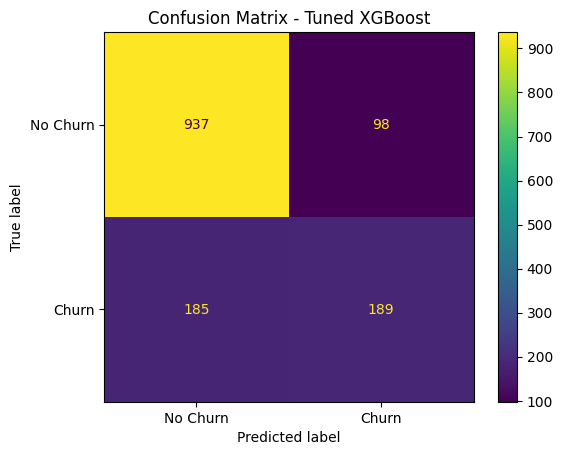

In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("Confusion Matrix - Tuned XGBoost")
plt.show()

### 13.2 Confusion Matrix Interpretation

The confusion matrix provides a detailed view of the tuned XGBoost model's predictions.

* **937 True Negatives:** Customers correctly predicted not to churn.
* **98 False Positives:** Customers predicted to churn who actually remained with the company.
* **185 False Negatives:** Customers predicted not to churn who actually churned.
* **189 True Positives:** Customers correctly identified as churners.

The model correctly identified 189 of the 374 customers who actually churned, corresponding to a recall of approximately 50.5%.

Although the model achieved relatively strong precision, a considerable number of actual churners were still missed. In a real retention setting, reducing false negatives and improving recall may be particularly important because missed churners cannot be targeted with retention strategies.


### 13.3 Classification Threshold

By default, the model classifies a customer as churn when the predicted probability is at least 0.5.

In a real retention setting, the threshold could be lowered to increase recall and identify more potential churners, although this would usually increase the number of false positives.

The appropriate threshold should depend on the business cost of missing a churner compared with the cost of targeting a customer who would not have churned.

## 14. Feature Importance

Feature importance is examined to understand which input variables contributed most to the XGBoost model's predictions.

Because categorical variables were one-hot encoded during preprocessing, the final model contains transformed feature names rather than only the original column names.

In [59]:
best_pipeline = xgb_random_search.best_estimator_

preprocessor_fitted = best_pipeline.named_steps["preprocessor"]
xgb_model_fitted = best_pipeline.named_steps["model"]

feature_names = preprocessor_fitted.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model_fitted.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
32,cat__Contract_Month-to-month,0.331208
14,cat__OnlineSecurity_No,0.106656
23,cat__TechSupport_No,0.084350
12,cat__InternetService_Fiber optic,0.081488
39,cat__PaymentMethod_Electronic check,0.053709
16,cat__OnlineSecurity_Yes,0.040467
34,cat__Contract_Two year,0.031182
42,remainder__tenure,0.023581
36,cat__PaperlessBilling_Yes,0.020083
15,cat__OnlineSecurity_No internet service,0.018251


### 14.1 Feature Importance Interpretation

The tuned XGBoost model identified month-to-month contracts as the most influential feature in its predictions.

Other important features included the absence of online security, absence of technical support, fiber-optic internet service, and electronic-check payments.

These results are consistent with several patterns identified during exploratory data analysis, where these customer groups also showed relatively high churn rates.

Customer tenure and total charges also contributed to the model, although their individual feature importance values were lower.

Feature importance reflects how useful a variable was to the predictive model and should not be interpreted as evidence that the variable directly causes customer churn.

### 14.2 Visualizing the Most Important Features

The top 15 features are visualized to make the relative importance of the strongest predictors easier to compare.

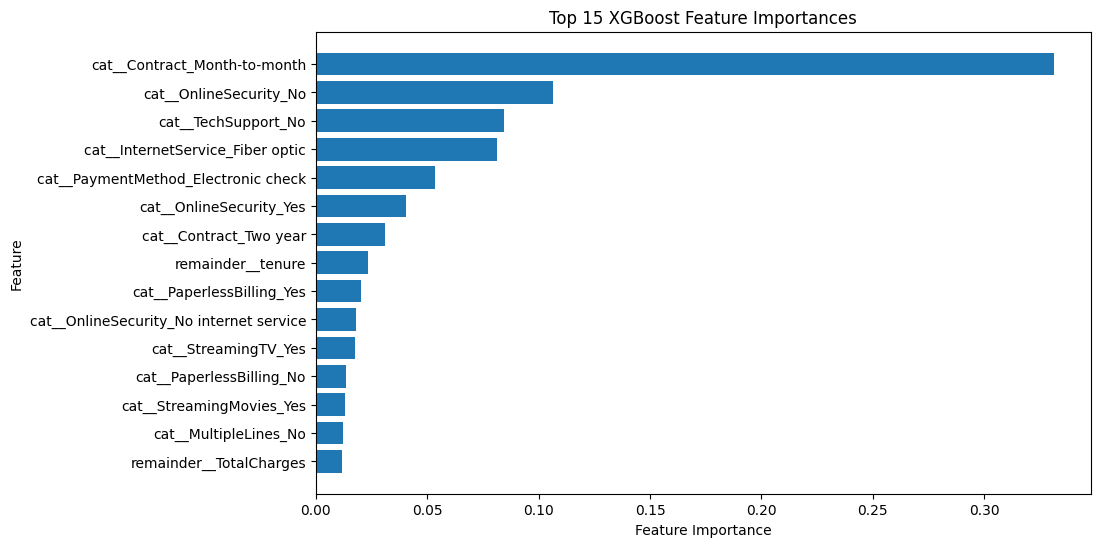

In [60]:
top_features = feature_importance.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

#### Interpretation

The feature importance visualization shows that month-to-month contracts had the strongest influence on the tuned XGBoost model.

The absence of online security and technical support, fiber-optic internet service, and electronic-check payments were also among the most influential features.

These findings support the patterns identified during EDA and indicate that contract type, service characteristics, and payment behavior played important roles in the model's churn predictions.

## 15. Business Insights

The analysis identified several customer characteristics associated with higher churn risk.

Key business insights include:

- Customers with month-to-month contracts showed much higher churn rates than customers with longer contracts.
- Customers with shorter tenure were more likely to churn, suggesting that newer customers may require additional retention attention.
- Fiber-optic customers showed relatively high churn rates.
- Customers using electronic checks were more likely to churn than customers using other payment methods.
- Customers without technical support or online security showed substantially higher churn rates.
- Higher monthly charges were also associated with churn.

These findings suggest that the company could focus retention efforts on customers with short tenure, month-to-month contracts, higher monthly charges, limited support services, or other high-risk characteristics identified by the model.

## 16. Final Conclusion

This project developed and evaluated several machine learning models to predict customer churn using the IBM Telco Customer Churn dataset.

A Decision Tree, Random Forest, and XGBoost model were compared using 5-fold cross-validation and multiple classification metrics.

The tuned XGBoost model achieved the strongest overall balance between precision and recall and was selected as the final model.

On the unseen test set, the tuned XGBoost model achieved approximately:

- **Accuracy:** 79.9%
- **Precision:** 65.9%
- **Recall:** 50.5%
- **F1-score:** 57.2%

The model successfully identified approximately half of the customers who actually churned, while maintaining relatively strong precision.

Feature importance analysis showed that month-to-month contracts, lack of online security, lack of technical support, fiber-optic internet service, and electronic-check payments were among the most influential predictive features.

Although the model provides useful predictive value, the recall indicates that many churners are still missed. In a real business setting, further work could include threshold optimization, additional feature engineering, alternative models, and evaluation of the financial impact of different retention strategies.

Overall, the project demonstrates a complete machine learning workflow including data exploration, cleaning, preprocessing, cross-validation, model comparison, hyperparameter tuning, final evaluation, and interpretation of model results.